## Linear Regression using Python

In [2]:
# importing some packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.metrics import r2_score

In [3]:
# read the csv file
data = pd.read_csv("mtcars.csv")

In [4]:
# Check out the shape of the data
data.shape

(32, 12)

In [5]:
# Check out first few lines of data

data.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


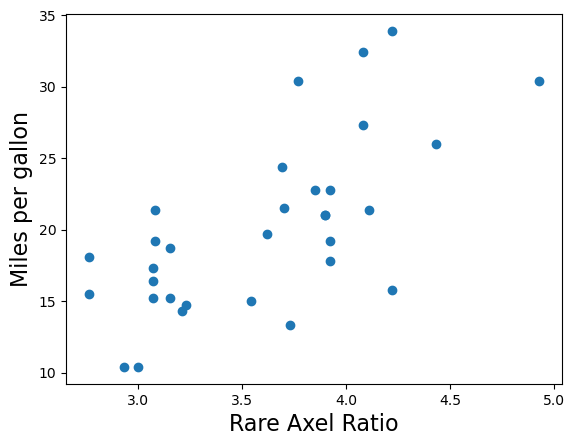

In [10]:
# EDA and Visualizations

plt.scatter(data['drat'],data['mpg'])
plt.xlabel('Rare Axel Ratio',fontsize =16);
plt.ylabel('Miles per gallon',fontsize=16);

# Fitting linear regression model using `drat`

$\text{mpg} = \alpha + \beta \texttt{ drat} + \varepsilon$

In [11]:
x = data[['drat']]
y = data[['mpg']]

In [12]:
y

,mpg
0,21.0
1,21.0
2,22.8
3,21.4
4,18.7
5,18.1
6,14.3
7,24.4
8,22.8
9,19.2


In [13]:
# Define linear regression model from linear model module of scikit learn pakage

In [14]:
lm = linear_model.LinearRegression()

In [15]:
fit_m1 = lm.fit(X=x,y=y)

In [18]:
intercept = fit_m1.intercept_
intercept

array([-7.52461844])

In [19]:
beta = fit_m1.coef_
beta

array([[7.6782326]])

In [22]:
y_hat = intercept + np.dot(x,beta)

# Estimate $\alpha$ and $\beta$ using OLS and check the value against the estimates of sklearn.

$y=X\beta+\varepsilon$

OLS Estimator: $\hat{\beta} = {X^TX}^{-1}X^Ty$

In [26]:
# First define the design matrix x

n = data.shape[0]
n

32

In [27]:
intercept_col = np.ones((n,1))
intercept_col

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.]])

In [28]:
X = np.hstack((intercept_col,x))

In [29]:
X

array([[1.  , 3.9 ],
       [1.  , 3.9 ],
       [1.  , 3.85],
       [1.  , 3.08],
       [1.  , 3.15],
       [1.  , 2.76],
       [1.  , 3.21],
       [1.  , 3.69],
       [1.  , 3.92],
       [1.  , 3.92],
       [1.  , 3.92],
       [1.  , 3.07],
       [1.  , 3.07],
       [1.  , 3.07],
       [1.  , 2.93],
       [1.  , 3.  ],
       [1.  , 3.23],
       [1.  , 4.08],
       [1.  , 4.93],
       [1.  , 4.22],
       [1.  , 3.7 ],
       [1.  , 2.76],
       [1.  , 3.15],
       [1.  , 3.73],
       [1.  , 3.08],
       [1.  , 4.08],
       [1.  , 4.43],
       [1.  , 3.77],
       [1.  , 4.22],
       [1.  , 3.62],
       [1.  , 3.54],
       [1.  , 4.11]])

In [30]:
Xt = np.transpose(X)

In [31]:
XtX = np.matmul(Xt,X)
XtX

array([[ 32.    , 115.09  ],
       [115.09  , 422.7907]])

In [33]:
XtX_inv = np.linalg.inv(XtX)
XtX_inv

array([[ 1.49082933, -0.40582621],
       [-0.40582621,  0.11283725]])

In [34]:
Xt_y = np.matmul(Xt,y)

In [36]:
beta_hat = np.matmul(XtX_inv,Xt_y)
beta_hat

,mpg
0,-7.524618
1,7.678233


In [38]:
[fit_m1.intercept_,fit_m1.coef_]

[array([-7.52461844]), array([[7.6782326]])]

# Draw the straight  line through the scatter plot

In [39]:
def abline(slope,intercept):
    axes = plt.gca()
    x_vals = np.array(axes.get_xlim())
    y_vals = intercept + slope*x_vals
    plt.plot(x_vals,y_vals,'--')

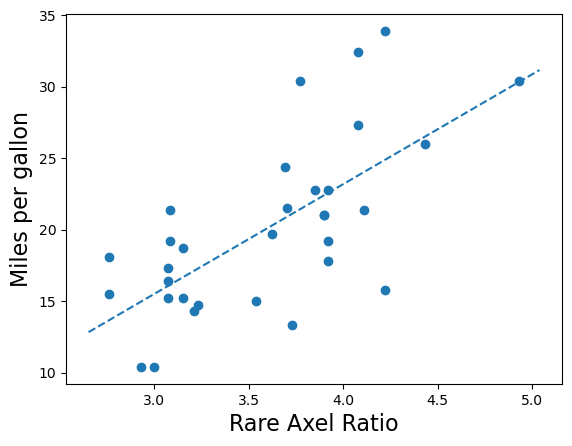

In [40]:
# EDA and Visualizations

plt.scatter(data['drat'],data['mpg'])
plt.xlabel('Rare Axel Ratio',fontsize =16);
plt.ylabel('Miles per gallon',fontsize=16);
abline(slope = 7.6782326,intercept= -7.52461844)

# Model Evaluation

In [41]:
 R2 = r2_score(y,y_hat)
R2

0.46399516798508655

In [ ]:
# 46 percent of the variability can be explained by dart column.